In [4]:
from EvenTem import Roi, vSTEM
import matplotlib.pyplot as plt
import numpy as np

In [5]:
filename = r"d:\DATA-local\zif8_210325\zif8\2025-03-21_11-29-12\raw000000.tpx3"
DetectorSize = 512
repetitions = 1
N = 2048
DwellTime = 5000

## First, use vSTEM to make a complete navigation image

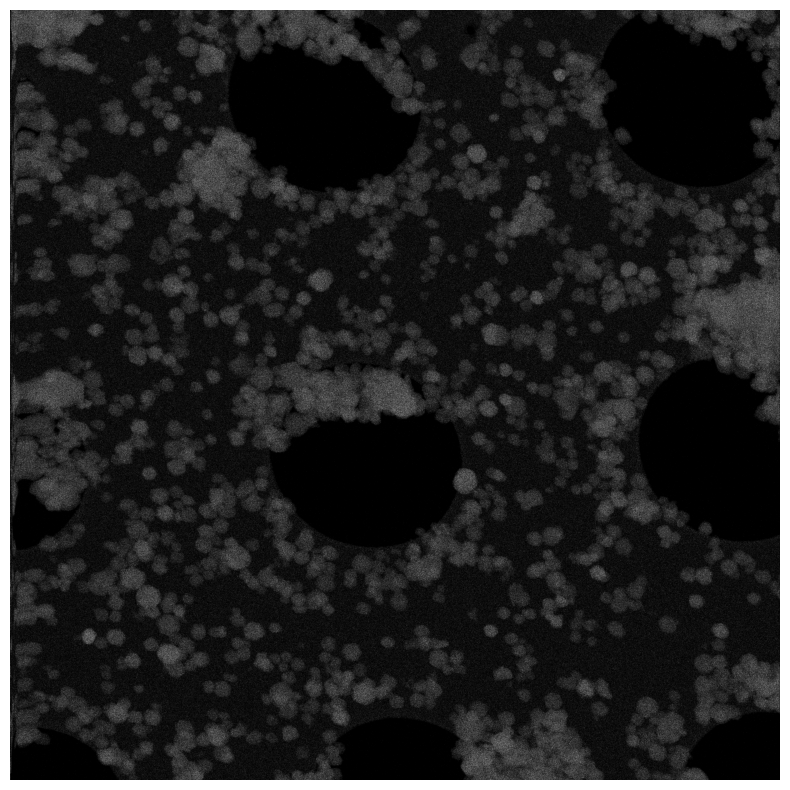

In [6]:
vs = vSTEM(nx=N,ny=N,repetitions=repetitions,filename=filename)
vs.DetectorSize = DetectorSize
vs.DwellTime = DwellTime
vs.InnerRadia = [50]
vs.OuterRadia = [vs.DetectorSize]
vs.Run()
vs.PlotImage()

## now we can select a region of interest
    remember, the axis convention is like 

    (0,0) ----------- axis 1
    |
    |
    |
    |
    |
    axis 0 

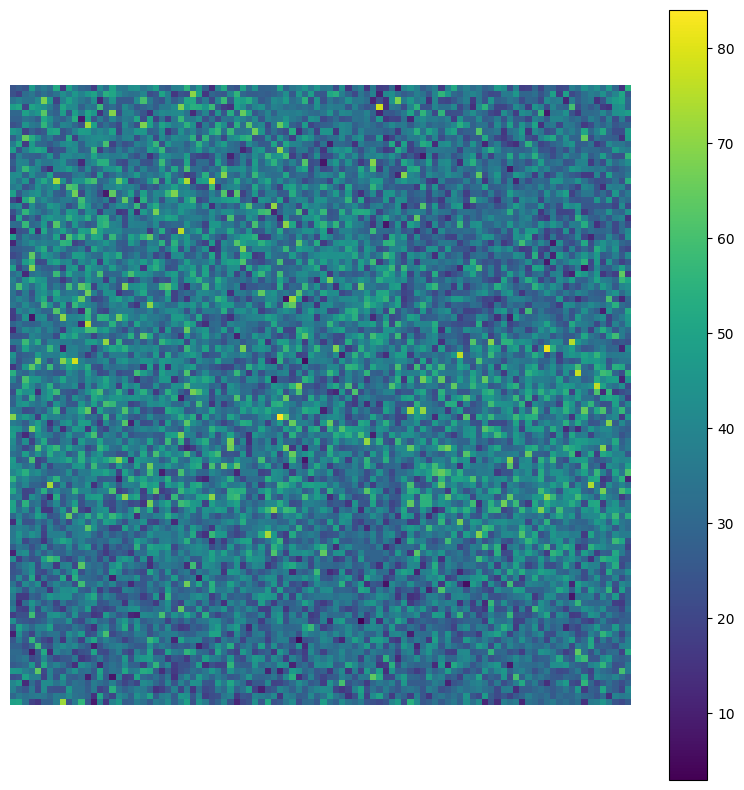

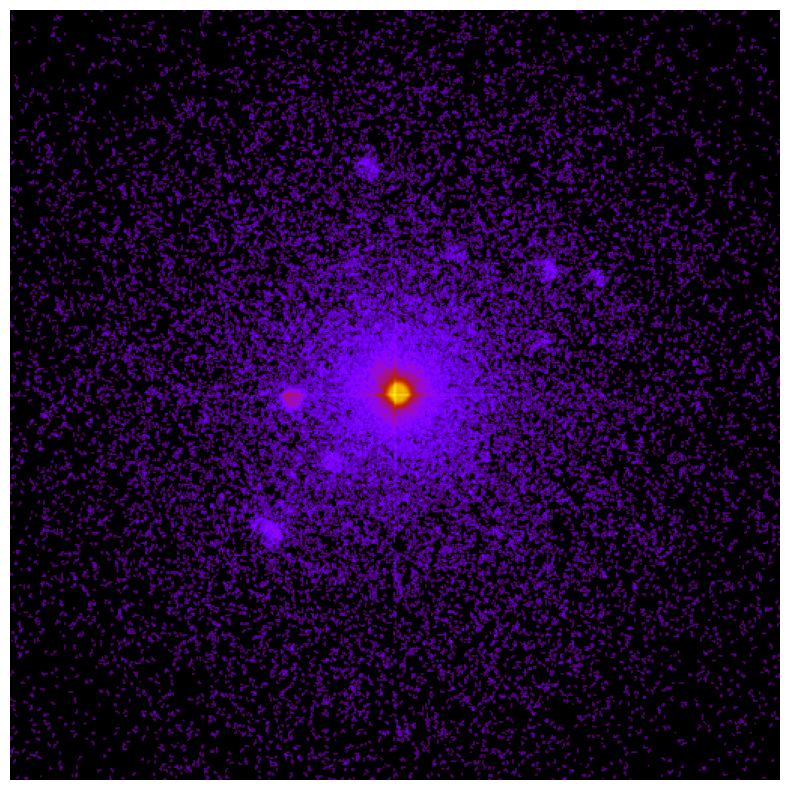

In [7]:
ROI = Roi(nx=N,ny=N,repetitions=repetitions,filename=filename,extract_4D=False)
ROI.DetectorSize = DetectorSize
ROI.DwellTime = DwellTime
ROI.SetROI(x_origin=256,y_origin=256,width=100,height=100)
ROI.Run()


scan_im = ROI.ScanImage
plt.figure(figsize=(10,10))
plt.imshow(scan_im)
plt.axis('off')
plt.colorbar()
plt.show()

det_im = ROI.DiffractionPattern
plt.figure(figsize=(10,10))
plt.imshow(np.log(det_im+1),cmap='gnuplot')
plt.axis('off')
plt.show()


In [8]:
ROI = Roi(nx=N,ny=N,repetitions=repetitions,filename=filename,extract_4D=True)
ROI.DetectorSize = DetectorSize
ROI.DwellTime = DwellTime #not relevant for simulation
ROI.ROI = (42,42,5,5) #x_origin,y_origin,width,height
ROI.DetectorBin = 2
ROI.Run()

extracting 4D sub-dataset that requires 0.00 GB of RAM


In [9]:
ROI_4D = ROI.Roi4D
print(f"ROI_4D shape: {ROI_4D.shape}")
print(f"ROI_4D dtype: {ROI_4D.dtype}")

ROI_4D shape: (5, 5, 256, 256)
ROI_4D dtype: uint8


(-0.5, 511.5, 511.5, -0.5)

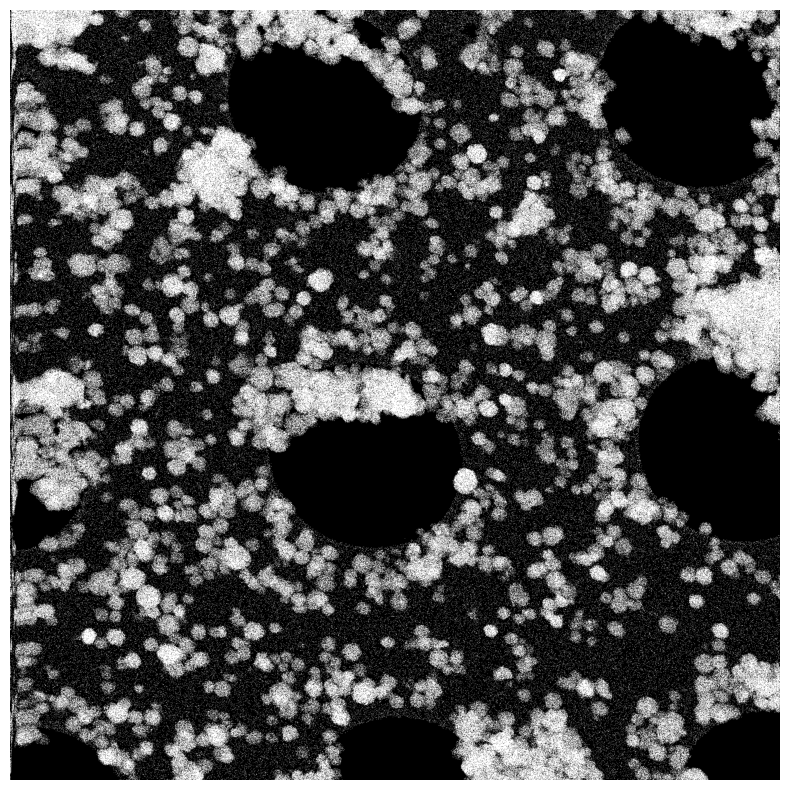

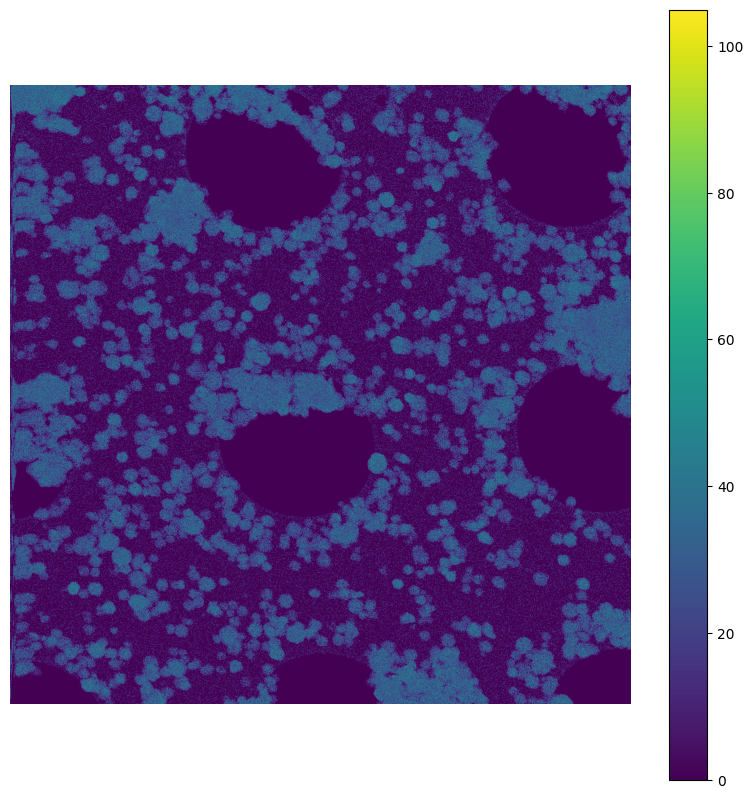

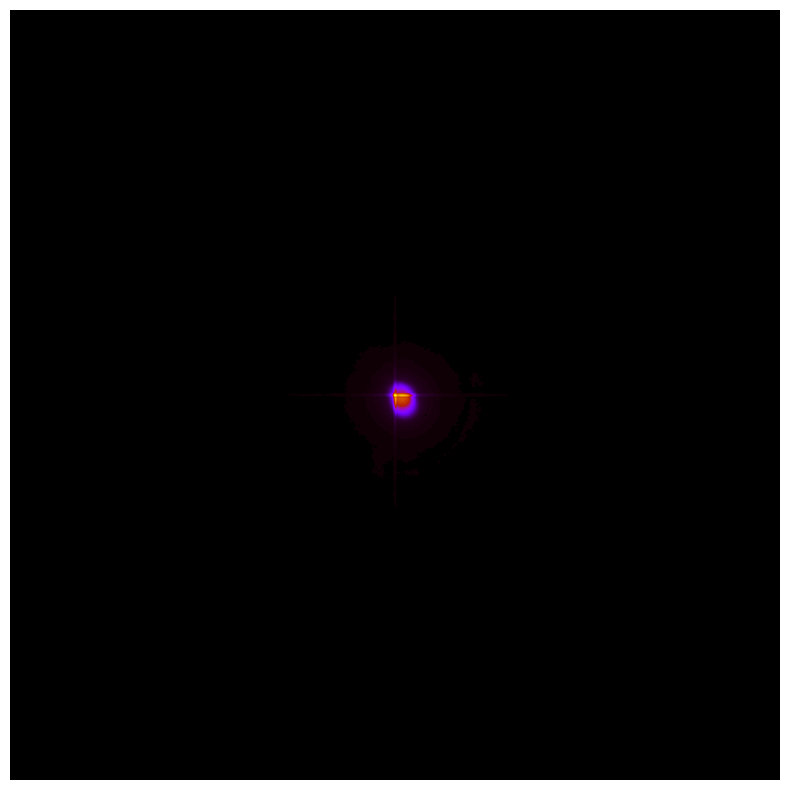

In [10]:
from skimage.filters import threshold_otsu

bin_mask = vs.image > threshold_otsu(vs.image)

plt.figure(figsize=(10,10))
plt.imshow(bin_mask, cmap='gray')
plt.axis('off')


ROI = Roi(nx=N,ny=N,repetitions=repetitions,filename=filename,extract_4D=False)
ROI.DetectorSize = DetectorSize
ROI.DwellTime = DwellTime #not relevant for simulation
ROI.SetROIMask([bin_mask])
ROI.Run()

scan_im = ROI.ScanImage
plt.figure(figsize=(10,10))
plt.imshow(scan_im)
plt.axis('off')
plt.colorbar()

det_im = ROI.DiffractionPattern
plt.figure(figsize=(10,10))
plt.imshow(det_im,cmap='gnuplot')
plt.axis('off')

## Beyond hit-counting: `tot_mode` and charge-weighted declustering

Everything above counted **raw hits**: every pixel event inside the ROI added 1 to the scan
image / diffraction pattern, regardless of how much charge it actually deposited. `Roi` has
two more ways to turn hits into an image, both switched on with a plain attribute (they don't
have `Set...`-style wrapper methods yet, so you set the raw C++ attribute directly -- that's
completely normal, `Roi` is a real Python object and every field on it is a live attribute):

- **`tot_mode = True`** -- each hit contributes its own ToT (time-over-threshold) value
  instead of a flat `+1`. ToT is roughly proportional to deposited charge, so this turns the
  scan image into "summed charge per probe position" instead of "hit count per probe
  position" -- useful when you care about dose/intensity, not just whether something arrived.
  No clustering involved; it's a per-hit reinterpretation, and it's off by default (`tot_mode`
  defaults to `False`, giving you the exact same hit-counting behavior as every cell above).

- **`decluster = True`** -- a real Timepix3 pixel almost never fires exactly once per electron:
  charge sharing between neighbouring pixels means one electron typically shows up as a small
  *cluster* of hits, close together in space and time. Declustering groups those hits back into
  electrons before counting, so the scan image reports **electron count**, not **hit count** --
  the two can differ by a factor of several. It needs four parameters, all mirroring
  `pyeventem`'s own `Declusterer` (see that project's `Examples/05_declustering_walkthrough.ipynb`
  if you want the full mechanics): `dspace` (pixels), `dtime` (in the file's own tick units --
  convert from nanoseconds with `round(dtime_ns / 1.5625)`), `cluster_range` (how many array
  positions ahead to search for a cluster's other members), and `tot_per_electron` (the
  ToT-per-electron calibration -- there's no safe default here, it depends on beam energy and
  detector threshold, so `decluster=True` with `tot_per_electron<=0` raises).

Both features only apply to raw `.tpx3` (CHEETAH) files -- they're meaningless for a
pre-converted `.electron` file, which has already been through this decision once.

The cells below use `pyeventem`'s own real `Full scan` test file (a sibling repo checkout,
`../../pyeventem/test_data/`) rather than the `filename` set at the top of this notebook, since
that path is specific to the notebook author's own machine. Adjust `filename` below to point at
any real `.tpx3` file you have.

In [2]:
real_filename = "../../pyeventem/test_data/Full scan/raw_0140_0.00_000000.tpx3"
real_N = 512
real_dwell_time = 100_000  # ns
real_roi_xywh = dict(x_origin=224, y_origin=224, width=64, height=64)

roi_hits = Roi(nx=real_N, ny=real_N, repetitions=1, filename=real_filename, extract_4D=False)
roi_hits.DwellTime = real_dwell_time
roi_hits.SetROI(**real_roi_xywh)
roi_hits.Run()
hit_total = int(np.sum(roi_hits.ScanImage))

roi_tot = Roi(nx=real_N, ny=real_N, repetitions=1, filename=real_filename, extract_4D=False)
roi_tot.DwellTime = real_dwell_time
roi_tot.SetROI(**real_roi_xywh)
roi_tot.tot_mode = True
roi_tot.Run()
tot_total = int(np.sum(roi_tot.ScanImage))

print(f"hit-count mode (default): scan image sum = {hit_total:,} (electron/hit count)")
print(f"tot_mode=True:            scan image sum = {tot_total:,} (summed ToT -- proportional to deposited charge)")
print(f"ratio: {tot_total / hit_total:.2f} ToT-units per hit on average, on this detector/threshold")

hit-count mode (default): scan image sum = 7,591,044 (electron/hit count)
tot_mode=True:            scan image sum = 330,193,376 (summed ToT -- proportional to deposited charge)
ratio: 43.50 ToT-units per hit on average, on this detector/threshold


In [3]:
import numpy as np  # note: this cell reuses roi_hits/hit_total computed in the tot_mode cell above

# Declustering parameters -- matching pyeventem's own real-data calibration for this exact
# file (see pyeventem/BENCHMARKS.md's "Declustering" section / Examples/05_declustering_walkthrough.ipynb),
# so the numbers below are directly comparable to that notebook's.
DSPACE = 6
DTIME_NS = 100.0
CLUSTER_RANGE = 256
TOT_PER_ELECTRON = 100.0
DTIME_TICKS = int(round(DTIME_NS / 1.5625))

# n_threads=8 matters here: declustering has its own, separate multi-threading model from the
# plain-hit-counting cells above (see BENCHMARKS.md) -- single-threaded, this ROI takes several
# minutes; with 8 threads, well under a minute on this machine.
roi_decl = Roi(nx=real_N, ny=real_N, repetitions=1, filename=real_filename, extract_4D=False)
roi_decl.DwellTime = real_dwell_time
roi_decl.SetROI(**real_roi_xywh)
roi_decl.decluster = True
roi_decl.dtime = DTIME_TICKS
roi_decl.dspace = DSPACE
roi_decl.cluster_range = CLUSTER_RANGE
roi_decl.tot_per_electron = TOT_PER_ELECTRON
roi_decl.n_threads = 8
roi_decl.Run()
decl_total = int(np.sum(roi_decl.ScanImage))

# Note: clustersize_histogram itself is NOT restricted to the ROI's x-width -- it's
# accumulated over every hit in the decoded row band (all 512 columns, not just this
# ROI's 64), since declustering runs on the raw hit stream before ROI cropping. So it
# isn't directly comparable to hit_total/decl_total (both of which ARE ROI-cropped);
# the ROI-restricted before/after comparison below is the fair one.
print(f"decluster=True: scan image sum = {decl_total:,} (declustered electron count, within this ROI)")
print(f"raw hits (hit-count mode, above): {hit_total:,} (within this ROI)")
print(f"{hit_total / decl_total:.2f} raw hits per declustered electron, on average, within this ROI")

decluster=True: scan image sum = 3,398,762 (declustered electron count, within this ROI)
raw hits (hit-count mode, above): 7,591,044 (within this ROI)
2.23 raw hits per declustered electron, on average, within this ROI


## Splitting a big file across several processes: `find_checkpoints`

A raw `.tpx3` file is decoded **sequentially** -- `n_threads` above never parallelizes the file
read/decode itself (it's a strictly ordered state machine: each of the four Timepix3 chips'
pixel-hit stream has to be walked in file order to track when each scan line starts and ends),
only some downstream per-frame work. So on a large file, one process reading top-to-bottom is
the whole story, however many threads you give it.

`Roi.find_checkpoints(n_splits)` is how you get real parallelism instead: it scans the file once
to find `n_splits - 1` interior points where the file can be safely cut into `n_splits` disjoint,
contiguous line ranges, each one independently decodable, along with everything a fresh process
needs to *resume* decoding correctly starting mid-file (the tricky part -- a chip resuming
mid-stream has no header of its own to re-derive its rise/fall timing state from, so that state
has to be handed to it explicitly). Each returned checkpoint is a
`(byte_offset, start_line, dt, rise_t[4], rise_fall[4], line_count[4], chip_id)` tuple. You then:

1. Start `n_splits` separate `Roi` objects, one per process.
2. Give worker *i* its slice's `file_byte_offset`/`line_number_offset` (where to seek to and what
   absolute line number that is) and `stop_at_line` (where to stop -- the *next* worker's start
   line, or `-1` for the last worker, meaning "read to the real end of file").
3. Seed every worker except the first (which starts at the real file beginning, where no seeding
   is needed) with its checkpoint's `dt`/`rise_t`/`rise_fall`/`line_count`/`chip_id` via the
   matching `seed_*` attributes.
4. Run all `n_splits` workers, then **sum** their `ScanImage`/`DiffractionPattern` results -- since
   the line ranges are disjoint, summing is exactly equivalent to one process having written every
   worker's own pixels itself.

Finding checkpoints normally means an expensive prescan of the whole file just to build them. If
`pyeventem` (the companion Python package) has already written a `<file>.tpx3scan` sidecar index
next to your `.tpx3` file -- either from a full decode, or explicitly via its
`pyeventem.tools.build_index` tool -- `find_checkpoints` reads that index directly instead of
prescanning, which is why the call below is near-instant even on a multi-gigabyte file. Without a
sidecar (`allow_sidecar=False`, or no matching `.tpx3scan` present), it automatically falls back to
the prescan -- always correct, just slower to set up. `vSTEM` has the exact same
`find_checkpoints`/`seed_*` interface; `Roi` is shown here since that's this notebook's subject.

In [4]:
probe = Roi(nx=real_N, ny=real_N, repetitions=1, filename=real_filename, extract_4D=False)
probe.DwellTime = real_dwell_time
probe.SetROI(**real_roi_xywh)

checkpoints = probe.find_checkpoints(4, True)  # (n_splits, allow_sidecar)
print(f"{len(checkpoints)} interior checkpoints for 4 workers (one less than n_splits):\n")
for byte_offset, start_line, dt, rise_t, rise_fall, line_count, chip_id in checkpoints:
    print(f"  byte_offset={byte_offset:>14,}  start_line={start_line:>4}  dt={dt}  chip_id={chip_id}")

3 interior checkpoints for 4 workers (one less than n_splits):

  byte_offset=   779,939,664  start_line= 128  dt=63999  chip_id=1
  byte_offset= 1,538,715,424  start_line= 256  dt=63999  chip_id=3
  byte_offset= 2,413,138,360  start_line= 384  dt=63999  chip_id=0


### Actually running the workers

The worker function that each process runs has to live in its own importable `.py` file, not a
notebook cell -- on Windows, `ProcessPoolExecutor` starts new processes with the "spawn" method,
which pickles a worker function by its import path (`module.function_name`) and re-imports that
module in the child process. A function defined inline in a notebook cell has no such importable
path, so it can't be sent to a child process this way. `_roi_mp_workers.py`, next to this notebook,
has the two small pieces needed: `build_worker_plan` (turns the checkpoint list into each worker's
`file_byte_offset`/`line_number_offset`/`stop_at_line`/seed dict, exactly per the steps above) and
`decode_one_slice` (what each worker process actually runs: build its own `Roi`, seed it, `.Run()`
it, return its `ScanImage`/`DiffractionPattern`).

The cell below builds a single-process reference first, then reruns the same ROI split across 4
processes and checks the summed result against it exactly.

In [5]:
import sys, time
sys.path.insert(0, ".")  # so "_roi_mp_workers" is importable by the worker processes too
from concurrent.futures import ProcessPoolExecutor
from _roi_mp_workers import decode_one_slice, build_worker_plan

# single-process reference
ref = Roi(nx=real_N, ny=real_N, repetitions=1, filename=real_filename, extract_4D=False)
ref.DwellTime = real_dwell_time
ref.SetROI(**real_roi_xywh)
t0 = time.perf_counter()
ref.Run()
t_ref = time.perf_counter() - t0
ref_scan = np.asarray(ref.ScanImage)
print(f"single-process reference: {t_ref:.2f}s   total = {int(ref_scan.sum()):,}")

n_workers = 4
plan = build_worker_plan(checkpoints, n_workers)
args = [
    (real_filename, real_N, real_N, real_dwell_time, tuple(real_roi_xywh.values()), fbo, lno, stop, seed)
    for fbo, lno, stop, seed in plan
]

t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=n_workers) as ex:
    results = list(ex.map(decode_one_slice, args))
elapsed = time.perf_counter() - t0

total_scan = sum(scan_image for scan_image, _ in results)
print(f"n_workers={n_workers}:             {elapsed:.2f}s   total = {int(total_scan.sum()):,}   "
      f"exact match vs. single-process reference: {np.array_equal(total_scan, ref_scan)}")

single-process reference: 4.87s   total = 7,591,044


n_workers=4:             3.50s   total = 7,591,044   exact match vs. single-process reference: True
